In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

In [2]:
# CONFIGURATION
model_path = "./vit_results/best_vit.pth"  
class_names = ['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']    
image_size = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
# IMAGE TRANSFORM (must match training)
mean = [0.1743, 0.1743, 0.1744]
std = [0.1701, 0.1701, 0.1702]
test_trans = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,
                         std=std),
])

In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

In [5]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x
        


In [6]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 num_classes=10, embed_dim=256, depth=6, num_heads=8, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(
            *[TransformerEncoderBlock(embed_dim, num_heads, dropout=dropout) for _ in range(depth)]
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        x = self.blocks(x)
        x = self.norm(x)
        cls_output = x[:, 0]
        return self.head(cls_output)

In [7]:
num_classes = len(class_names)
model = VisionTransformer(img_size=image_size, num_classes=num_classes).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(" Loaded trained Vision Transformer model.")


 Loaded trained Vision Transformer model.


In [8]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = test_trans(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)
        predicted_class = class_names[pred_idx.item()]
        confidence = conf.item() * 100

    # visualize result
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    print(f"🖼️ Image: {os.path.basename(image_path)}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

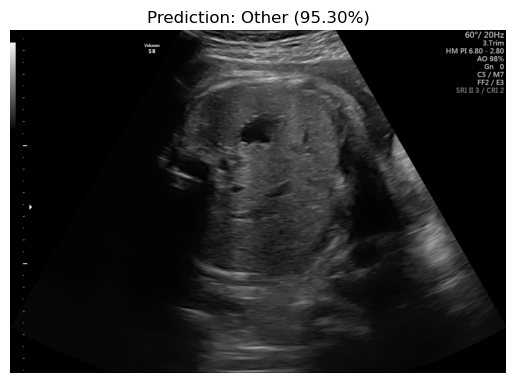

🖼️ Image: Patient00631_Plane2_1_of_1.png
Predicted class: Other
Confidence: 95.30%


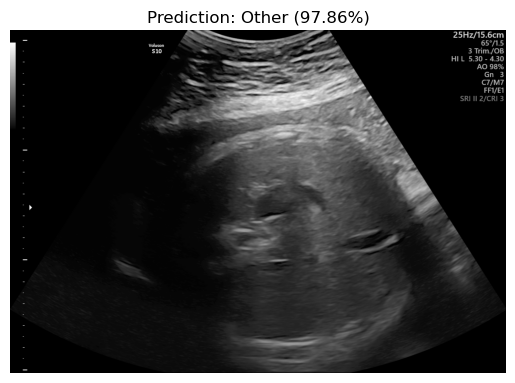

🖼️ Image: Patient01780_Plane2_2_of_2.png
Predicted class: Other
Confidence: 97.86%


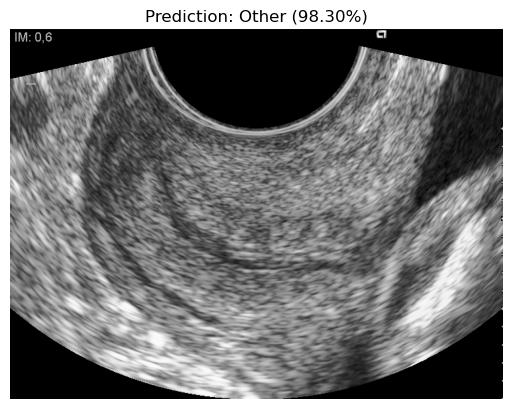

🖼️ Image: Patient00227_Plane4_1_of_1.png
Predicted class: Other
Confidence: 98.30%


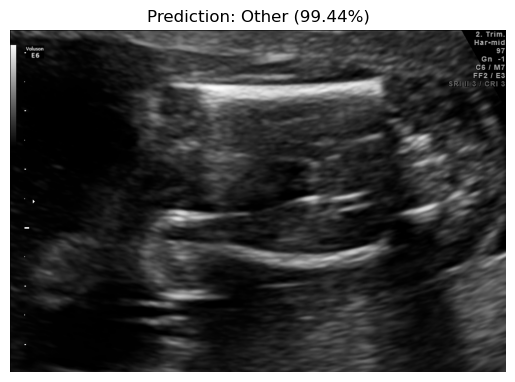

🖼️ Image: Patient00823_Plane5_1_of_1.png
Predicted class: Other
Confidence: 99.44%


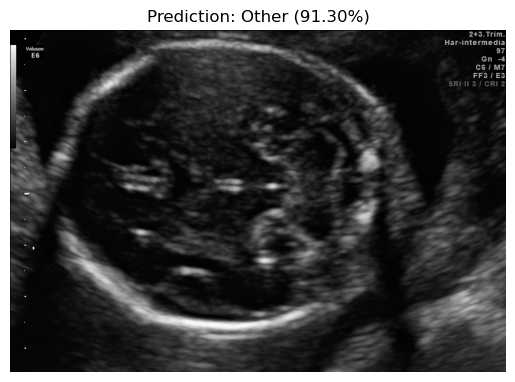

🖼️ Image: Patient01239_Plane3_6_of_6.png
Predicted class: Other
Confidence: 91.30%


In [9]:
image_paths = [
    "trainable_dataset/test/Fetal Abdomen/Patient00631_Plane2_1_of_1.png",   # <-- replace with your image path
    "trainable_dataset/test/Fetal Abdomen/Patient01780_Plane2_2_of_2.png",
    "trainable_dataset/test/Maternal Cervix/Patient00227_Plane4_1_of_1.png",
    "trainable_dataset/test/Fetal Femur/Patient00823_Plane5_1_of_1.png",
    "trainable_dataset/test/Fetal Brain/Patient01239_Plane3_6_of_6.png"
]

for path in image_paths:
    if os.path.exists(path):
        predict_image(path)
    else:
        print(f"⚠️ File not found: {path}")